# СЛЕПО ПРЕБАРУВАЊЕ

# Претставуање на граф преку речник

In [55]:
class Graph():
    def __init__(self):
        """
        Initialises an empty dict as the graph data structure.
        """
        self.graph_dict = {}
    
    def add_vertex(self, vertex):
        """
        Adds a vertex to the graph. 
        
        Args:
            vertex: vertex to be added in the graph
        """
        if vertex not in self.graph_dict:
            self.graph_dict[vertex] = []
    
    def vertices(self):
        """
        Returns the graph's vertices.
        """
        return list(self.graph_dict.keys())
    
    def add_edge(self, edge, add_reversed=True):
        """
        Adds an edge to the graph.
        
        Args:
            edge: a tupple of two vertices, (first_vertex, second_vertex)
            add_reversed: whether to add the edge in reversed direction, (second_vertex, first_vertex)
        """
        vertex1, vertex2 = edge
        self.graph_dict[vertex1].append(vertex2)
        if add_reversed:
            self.graph_dict[vertex2].append(vertex1)
    
    def edges(self):
        """
        Returns a list of all edges in the graph.
        """
        edges = []
        for vertex in self.graph_dict:
            for neighbour in self.graph_dict[vertex]:
                edges.append((vertex, neighbour))
        return edges
    
    def neighbours(self, vertex):
        """
        Returns all neighbours of the given vertex.
        """
        return self.graph_dict[vertex]
    
    def remove_vertex(self, vertex_to_remove):
        """
        Removes a vertex from the graph.
        
        First, the vertex's list is removed.
        Then, we remove all the occurances of the vertex in another vertex's list.
        
        Args:
            vertex_to_remove: the vertex to be removed.
        """
        del self.graph_dict[vertex_to_remove]
        for vertex in self.vertices():
            if vertex_to_remove in self.graph_dict[vertex]:
                self.graph_dict[vertex].remove(vertex_to_remove)

    def remove_edge(self, edge_to_remove, remove_reversed=True):
        """
        Removes an edge from the graph.
        
        Args:
            edge_to_remove: the edge to be removed
            remove_reversed: whether to remove the edge in reversed direction
        """
        vertex1, vertex2 = edge_to_remove
        if vertex2 in self.graph_dict[vertex1]:
            self.graph_dict[vertex1].remove(vertex2)
        if remove_reversed:
            if vertex1 in self.graph_dict[vertex2]:
                self.graph_dict[vertex2].remove(vertex1)

    def isolated_vertices(self):
        """
        Returns a list of all isolated vertices.
        """
        isolated_vertices = []
        for vertex in self.graph_dict:
            if not self.graph_dict[vertex]:
                isolated_vertices.append(vertex)
        return isolated_vertices

In [56]:
g = Graph() # definirame recnik za graf

In [57]:
g.add_vertex('S')    # dodavame teminja na grafot
g.add_vertex('A')
g.add_vertex('B')
g.add_vertex('C')
g.add_vertex('D')
g.add_vertex('E')
g.add_vertex('F')
g.add_vertex('G')
g.add_vertex('H')

In [58]:
g.vertices()  # ni gi vrakja site jazli

['S', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

In [59]:
g.add_edge(('S', 'A')) # dodavame sosedi
g.add_edge(('S', 'C'))
g.add_edge(('S', 'G'))
g.add_edge(('A', 'B'))
g.add_edge(('C', 'D'))
g.add_edge(('C', 'E'))
g.add_edge(('C', 'F'))
g.add_edge(('G', 'F'))
g.add_edge(('G', 'H'))
g.add_edge(('E', 'H'))

In [60]:
g.edges()  #citanje na site sosedi

[('S', 'A'),
 ('S', 'C'),
 ('S', 'G'),
 ('A', 'S'),
 ('A', 'B'),
 ('B', 'A'),
 ('C', 'S'),
 ('C', 'D'),
 ('C', 'E'),
 ('C', 'F'),
 ('D', 'C'),
 ('E', 'C'),
 ('E', 'H'),
 ('F', 'C'),
 ('F', 'G'),
 ('G', 'S'),
 ('G', 'F'),
 ('G', 'H'),
 ('H', 'G'),
 ('H', 'E')]

In [61]:
g.neighbours('S') # sosedi na jazol 'S'

['A', 'C', 'G']

# Пребарување по широчина

In [62]:
from collections import deque

In [63]:
def breadth_first_search_find_path(graph, starting_vertex, goal_vertex, verbose=False):
    """
    Returns the path from starting_vertex to goal_vertex using the DFS algorithm.
    """
    # Ако почетниот јазол е еднаков на целниот, тогаш нема логика да пребаруваме воопшто
    if starting_vertex == goal_vertex:
        if verbose:
            print('Почетниот и бараниот јазол се исти')
        return []
    # Користиме листа на посетени јазли која всушност е податочна структура множество. 
    # За посетен јазол го сметаме оној јазол кој ќе го истражиме како сосед на јазолот кој го разгрануваме.
    visited = {starting_vertex}
    # Користиме двојно поврзана листа која ни е редицата од која ќе го земаме следниот јазол за разгранување.
    # Тука ја памтиме и моменталната патека за секој јазол од почетниот.
    queue = deque([[starting_vertex]])
    # Пребаруваме сѐ додека има јазли за разгранување во редицата.
    while queue:
        if verbose:
            print('Ред за разгранување:')
            for element in queue:
                print(element, end=' ')
            print()
            print()
        # Членови на редицата јазли се патеките од почетниот јазол до некој јазол кој треба да се разграни.
        # За да го земаме наредниот јазол за разгранување, 
        #    ние треба од редицата да ја извадиме патеката на тој јазол.
        vertex_list = queue.popleft()
        # Јазолот за разгранување е послениот во оваа листа.
        vertex_to_expand = vertex_list[-1]
        if verbose:
            print('Го разгрануваме јазолот {}'.format(vertex_to_expand))
        # Го разгрануваме така што пребаруваме низ сите негови соседи.
        for neighbour in graph.neighbours(vertex_to_expand):
            if neighbour in visited:
                if verbose:
                    print('{} е веќе посетен'.format(neighbour))
            else:
                # Ако некој сосед не е посетен, тогаш го додаваме во листата на посетени, 
                #     и во редицата на јазли за разгранување.
                if verbose:
                    print('{}, кој е соседен јазол на {} го немаме посетено до сега, затоа го додаваме во редот '
                          'за разгранување и го означуваме како посетен'.format(neighbour, vertex_to_expand))
                # Тука ја вршиме проверката дали сме стигнале до целниот јазол 
                if neighbour == goal_vertex:
                    if verbose:
                        print('Го пронајдовме посакуваниот јазол {}. Патеката да стигнеме до тука е {}'
                              .format(neighbour, vertex_list + [neighbour]))
                    return vertex_list + [neighbour]
                visited.add(neighbour)
                # Бидејќи ова е пребарување прво по широчина, 
                #     соседот го додаваме на крајот од редицата јазли за разгранување.
                # Соседот го врзуваме со патеката од почетниот јазол до моменталниот кој го разгрануваме.
                queue.append(vertex_list + [neighbour])
        if verbose:
            print()

In [64]:
breadth_first_search_find_path(g, 'S', 'E', verbose=True)

Ред за разгранување:
['S'] 

Го разгрануваме јазолот S
A, кој е соседен јазол на S го немаме посетено до сега, затоа го додаваме во редот за разгранување и го означуваме како посетен
C, кој е соседен јазол на S го немаме посетено до сега, затоа го додаваме во редот за разгранување и го означуваме како посетен
G, кој е соседен јазол на S го немаме посетено до сега, затоа го додаваме во редот за разгранување и го означуваме како посетен

Ред за разгранување:
['S', 'A'] ['S', 'C'] ['S', 'G'] 

Го разгрануваме јазолот A
S е веќе посетен
B, кој е соседен јазол на A го немаме посетено до сега, затоа го додаваме во редот за разгранување и го означуваме како посетен

Ред за разгранување:
['S', 'C'] ['S', 'G'] ['S', 'A', 'B'] 

Го разгрануваме јазолот C
S е веќе посетен
D, кој е соседен јазол на C го немаме посетено до сега, затоа го додаваме во редот за разгранување и го означуваме како посетен
E, кој е соседен јазол на C го немаме посетено до сега, затоа го додаваме во редот за разгранување и

['S', 'C', 'E']

# Пребарување по длабочина

In [65]:
def depth_first_search_find_path(graph, starting_vertex, goal_vertex, verbose=False):
    """
    Returns the path from starting_vertex to goal_vertex using the BFS algorithm.
    """
    # Ако почетниот јазол е еднаков на целниот, тогаш нема логика да пребаруваме воопшто
    if starting_vertex == goal_vertex:
        if verbose:
            print('Почетниот и бараниот јазол се исти')
        return []
    # Користиме листа на посетени јазли која всушност е податочна структура множество. 
    # За посетен јазол го сметаме оној јазол кој ќе го истражиме како сосед на јазолот кој го разгрануваме.
    visited = {starting_vertex}
    # Користиме двојно поврзана листа која ни е редицата од која ќе го земаме следниот јазол за разгранување.
    # Тука ја памтиме и моменталната патека за секој јазол од почетниот.
    queue = deque([[starting_vertex]])
    # Пребаруваме сѐ додека има јазли за разгранување во редицата.
    while queue:
        if verbose:
            print('Ред за разгранување:')
            for element in queue:
                print(element, end=' ')
            print()
            print()
        # Членови на редицата јазли се патеките од почетниот јазол до некој јазол кој треба да се разграни.
        # За да го земаме наредниот јазол за разгранување, 
        #    ние треба од редицата да ја извадиме патеката на тој јазол.
        vertex_list = queue.popleft()
        # Јазолот за разгранување е послениот во оваа листа.
        vertex_to_expand = vertex_list[-1]
        if verbose:
            print('Го разгрануваме јазолот {}'.format(vertex_to_expand))
        # Го разгрануваме така што пребаруваме низ сите негови соседи.
        for neighbour in graph.neighbours(vertex_to_expand):
            if neighbour in visited:
                if verbose:
                    print('{} е веќе посетен'.format(neighbour))
            else:
                # Ако некој сосед не е посетен, тогаш го додаваме во листата на посетени, 
                #     и во редицата на јазли за разгранување.
                if verbose:
                    print('{}, кој е соседен јазол на {} го немаме посетено до сега, затоа го додаваме во редот '
                          'за разгранување и го означуваме како посетен'.format(neighbour, vertex_to_expand))
                # Тука ја вршиме проверката дали сме стигнале до целниот јазол 
                if neighbour == goal_vertex:
                    if verbose:
                        print('Го пронајдовме посакуваниот јазол {}. Патеката да стигнеме до тука е {}'
                              .format(neighbour, vertex_list + [neighbour]))
                    return vertex_list + [neighbour]
                visited.add(neighbour)
                # Бидејќи ова е пребарување прво по длабочина, 
                #     соседот го додаваме на почетокот од редицата јазли за разгранување.
                # Соседот го врзуваме со патеката од почетниот јазол до моменталниот кој го разгрануваме.
                queue.appendleft(vertex_list + [neighbour])
        if verbose:
            print()

In [66]:
depth_first_search_find_path(g, 'S', 'E', verbose=True)

Ред за разгранување:
['S'] 

Го разгрануваме јазолот S
A, кој е соседен јазол на S го немаме посетено до сега, затоа го додаваме во редот за разгранување и го означуваме како посетен
C, кој е соседен јазол на S го немаме посетено до сега, затоа го додаваме во редот за разгранување и го означуваме како посетен
G, кој е соседен јазол на S го немаме посетено до сега, затоа го додаваме во редот за разгранување и го означуваме како посетен

Ред за разгранување:
['S', 'G'] ['S', 'C'] ['S', 'A'] 

Го разгрануваме јазолот G
S е веќе посетен
F, кој е соседен јазол на G го немаме посетено до сега, затоа го додаваме во редот за разгранување и го означуваме како посетен
H, кој е соседен јазол на G го немаме посетено до сега, затоа го додаваме во редот за разгранување и го означуваме како посетен

Ред за разгранување:
['S', 'G', 'H'] ['S', 'G', 'F'] ['S', 'C'] ['S', 'A'] 

Го разгрануваме јазолот H
G е веќе посетен
E, кој е соседен јазол на H го немаме посетено до сега, затоа го додаваме во редот з

['S', 'G', 'H', 'E']

# 02 Задачи слепо пребарување

## Претурање вода во садови

Имате на располагање 3 садови. Нивниот капацитет е 5, 8 и 10 соодветно.  На почетокот сите садови се празни. Задачата е да претурите 1 литар во садот од 5 литри. Можете да претурате вода меѓу садовите, но не знаете точно колку претурате бидејќи садовите не се обележани. Единствено може да го испразните садот од кој претурате или да го наполните до врв садот во кој претурате. Постои и чешма од која може да надополните некој сад до врвот. Секогаш може да ја истурите водата од некој сад. Скратено: имате на располагање 3 садови. Нивниот капацитет е (x, y, z) соодветно. Почетната состојба е (x_0, y_0, z_0). Задачата е да стигнете до посакуваната состојба.

In [67]:
from collections import deque
from itertools import combinations

In [68]:
def transfer_to_other_glass(source, sink, sink_capacity):
    return max(source - (sink_capacity - sink), 0), min(sink + source, sink_capacity)

In [69]:
def expand_state(state):
    capacities = (5, 8, 10)
    glass_0, glass_1, glass_2 = state

    new_states = []

    if glass_0 < capacities[0]:
        new_states.append((capacities[0], glass_1, glass_2))
    if glass_1 < capacities[1]:
        new_states.append((glass_0, capacities[1], glass_2))
    if glass_2 < capacities[2]:
        new_states.append((glass_0, glass_1, capacities[2]))
    
    if glass_0 > 0:
        new_states.append((0, glass_1, glass_2))
    if glass_1 > 0:
        new_states.append((glass_0, 0, glass_2))
    if glass_2 > 0:
        new_states.append((glass_0, glass_1, 0))

    new_source, new_sink = transfer_to_other_glass(glass_0, glass_1, capacities[1])
    new_states.append((new_source, new_sink, glass_2))

    new_source, new_sink = transfer_to_other_glass(glass_1, glass_0, capacities[0])
    new_states.append((new_sink, new_source, glass_2))

    new_source, new_sink = transfer_to_other_glass(glass_0, glass_2, capacities[2])
    new_states.append((new_source, glass_1, new_sink))

    new_source, new_sink = transfer_to_other_glass(glass_2, glass_0, capacities[0])
    new_states.append((new_sink, glass_1, new_source))

    new_source, new_sink = transfer_to_other_glass(glass_1, glass_2, capacities[2])
    new_states.append((glass_0, new_source, new_sink))

    new_source, new_sink = transfer_to_other_glass(glass_2, glass_1, capacities[1])
    new_states.append((glass_0, new_sink, new_source))
    
    return new_states

In [73]:
def search_path(initial_state, goal_state):
    visited = {initial_state}
    states_queue = deque([[initial_state]])
    while states_queue:
        states_list = states_queue.popleft()
        state_to_expand = states_list[-1]
        for next_state in expand_state(state_to_expand):
            if next_state not in visited:
                if next_state == goal_state:
                    return states_list + [next_state]
                visited.add(next_state)
                states_queue.append(states_list + [next_state])
    return []

In [75]:
def visualise_path(path):
    for states in zip(path, path[1:]):
        old_state, new_state = states
        print(old_state)
        print(tuple(map(lambda x, y: x - y, new_state, old_state)), 'change')
        print(new_state)
        print()

In [78]:
inital_state = (0,0,0)
goal_state = (1,0,0)
path = search_path(inital_state, goal_state)
visualise_path(path)


(0, 0, 0)
(0, 8, 0) change
(0, 8, 0)

(0, 8, 0)
(5, -5, 0) change
(5, 3, 0)

(5, 3, 0)
(-5, 0, 0) change
(0, 3, 0)

(0, 3, 0)
(3, -3, 0) change
(3, 0, 0)

(3, 0, 0)
(0, 8, 0) change
(3, 8, 0)

(3, 8, 0)
(0, -8, 8) change
(3, 0, 8)

(3, 0, 8)
(-2, 0, 2) change
(1, 0, 10)

(1, 0, 10)
(0, 0, -10) change
(1, 0, 0)



In [79]:
from collections import deque
import os

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
data = load_iris()
print('Classes to predict: ', data.target_names)

Classes to predict:  ['setosa' 'versicolor' 'virginica']


In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('data/fruits_train.csv')
df

,vitamin A %,vitamin C %,calcium %,iron %,magnesium %,calories (per 100g),potassium (mg),protein (g),fiber (g),classification
0,1.0,7.0,0.0,0.0,1.0,52.0,107.0,0.3,2.4,fruit
1,38.0,16.0,1.0,2.0,2.0,48.0,259.0,1.4,2.0,fruit
2,2.0,16.0,1.0,3.0,7.0,160.0,485.0,2.0,7.0,fruit
3,1.0,14.0,0.0,1.0,6.0,89.0,358.0,1.1,2.6,fruit
4,0.0,8.0,1.0,1.0,5.0,43.0,325.0,1.6,2.8,vegetable
5,4.0,35.0,2.0,3.0,5.0,43.0,163.0,1.4,5.0,fruit
6,1.0,16.0,0.0,1.0,1.0,57.0,77.0,0.7,2.4,fruit
7,12.0,148.0,4.0,3.0,5.0,34.0,316.0,2.8,2.6,vegetable
8,15.0,141.0,4.0,7.0,5.0,43.0,389.0,3.4,3.8,vegetable
9,334.0,9.0,3.0,1.0,3.0,41.0,320.0,0.9,2.8,vegetable


In [9]:
df_y = df['classification']
df_x = df.iloc[:, :-1]

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_x, df_y, test_size=0.3, random_state=155)
df_test_x

,vitamin A %,vitamin C %,calcium %,iron %,magnesium %,calories (per 100g),potassium (mg),protein (g),fiber (g)
27,170.0,15.0,2.0,4.0,3.0,26.0,340.0,1.0,0.5
31,13.0,44.0,3.0,1.0,3.0,53.0,166.0,0.8,1.8
18,0.0,88.0,2.0,3.0,2.0,29.0,138.0,1.1,2.8
0,1.0,7.0,0.0,0.0,1.0,52.0,107.0,0.3,2.4
17,33.0,20.0,5.0,11.0,7.0,61.0,180.0,1.5,1.8
28,187.0,46.0,9.0,15.0,19.0,23.0,558.0,2.9,2.2
2,2.0,16.0,1.0,3.0,7.0,160.0,485.0,2.0,7.0
29,0.0,97.0,1.0,2.0,3.0,33.0,153.0,0.7,2.0
14,0.0,3.0,0.0,1.0,3.0,25.0,229.0,1.0,3.0
16,2.0,6.0,1.0,1.0,1.0,67.0,191.0,0.6,0.9


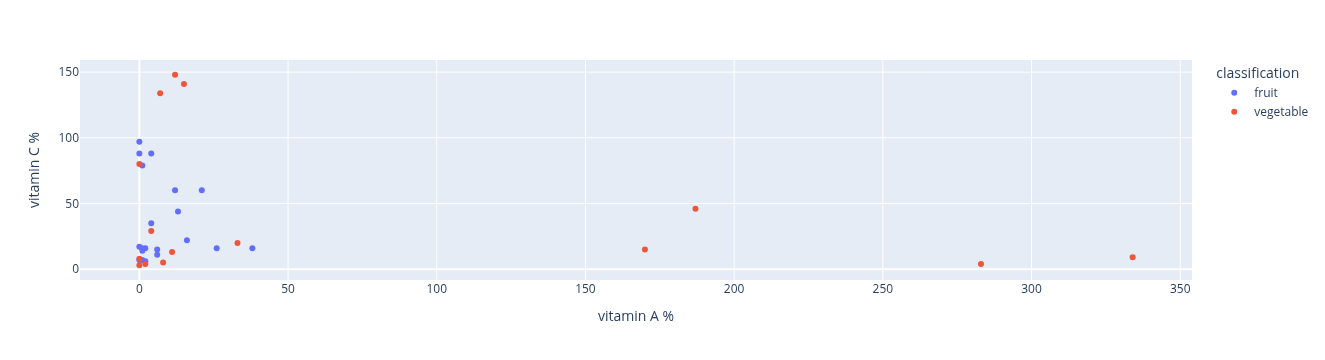

In [15]:
import plotly.express as px
px.scatter(df, x="vitamin A %", y="vitamin C %", color="classification")

In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(df_train_x, df_train_y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [18]:
df_pred_y = clf.predict(df_test_x)
df_pred_y

array(['vegetable', 'fruit', 'vegetable', 'fruit', 'fruit', 'vegetable',
       'fruit', 'vegetable', 'fruit', 'fruit', 'vegetable'], dtype=object)

In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(df_test_y, df_pred_y)

0.6363636363636364

In [20]:
accuracy_score(df_train_y, clf.predict(df_train_x))

1.0

In [21]:
df_high_calorie = df[df['calories (per 100g)'] > 50]
df_low_calorie = df[df['calories (per 100g)'] <= 50]
df_low_calorie

,vitamin A %,vitamin C %,calcium %,iron %,magnesium %,calories (per 100g),potassium (mg),protein (g),fiber (g),classification
1,38.0,16.0,1.0,2.0,2.0,48.0,259.0,1.4,2.0,fruit
4,0.0,8.0,1.0,1.0,5.0,43.0,325.0,1.6,2.8,vegetable
5,4.0,35.0,2.0,3.0,5.0,43.0,163.0,1.4,5.0,fruit
7,12.0,148.0,4.0,3.0,5.0,34.0,316.0,2.8,2.6,vegetable
8,15.0,141.0,4.0,7.0,5.0,43.0,389.0,3.4,3.8,vegetable
9,334.0,9.0,3.0,1.0,3.0,41.0,320.0,0.9,2.8,vegetable
10,0.0,80.0,2.0,2.0,3.0,25.0,299.0,1.9,2.0,vegetable
11,8.0,5.0,4.0,1.0,2.0,16.0,260.0,0.7,1.6,vegetable
12,26.0,16.0,1.0,1.0,2.0,50.0,173.0,1.0,1.6,fruit
13,2.0,4.0,1.0,1.0,3.0,16.0,147.0,0.7,0.5,vegetable


In [22]:
df_high_calorie_y = df_high_calorie['classification']
df_high_calorie_x = df_high_calorie.iloc[:, :-1]
accuracy_score(df_high_calorie_y, clf.predict(df_high_calorie_x))

0.9166666666666666

In [23]:
df_low_calorie_y = df_low_calorie['classification']
df_low_calorie_x = df_low_calorie.iloc[:, :-1]
accuracy_score(df_low_calorie_y, clf.predict(df_low_calorie_x))

0.8695652173913043

In [24]:
df_new = pd.read_csv('data/fruits_test.csv')
df_new

,vitamin A %,vitamin C %,calcium %,iron %,magnesium %,calories (per 100g),potassium (mg),protein (g),fiber (g)
0,1.0,154.0,3.0,1.0,4.0,61.0,213.0,1.1,3.0
1,15.0,300.0,2.0,11.0,3.0,20.0,202.0,2.2,2.1
2,0.0,43.0,2.0,3.0,5.0,53.0,151.0,1.1,7.0


In [25]:
clf.predict(df_new)

array(['fruit', 'vegetable', 'fruit'], dtype=object)

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('data/fruits_train.csv')
df

,vitamin A %,vitamin C %,calcium %,iron %,magnesium %,calories (per 100g),potassium (mg),protein (g),fiber (g),classification
0,1.0,7.0,0.0,0.0,1.0,52.0,107.0,0.3,2.4,fruit
1,38.0,16.0,1.0,2.0,2.0,48.0,259.0,1.4,2.0,fruit
2,2.0,16.0,1.0,3.0,7.0,160.0,485.0,2.0,7.0,fruit
3,1.0,14.0,0.0,1.0,6.0,89.0,358.0,1.1,2.6,fruit
4,0.0,8.0,1.0,1.0,5.0,43.0,325.0,1.6,2.8,vegetable
5,4.0,35.0,2.0,3.0,5.0,43.0,163.0,1.4,5.0,fruit
6,1.0,16.0,0.0,1.0,1.0,57.0,77.0,0.7,2.4,fruit
7,12.0,148.0,4.0,3.0,5.0,34.0,316.0,2.8,2.6,vegetable
8,15.0,141.0,4.0,7.0,5.0,43.0,389.0,3.4,3.8,vegetable
9,334.0,9.0,3.0,1.0,3.0,41.0,320.0,0.9,2.8,vegetable


In [5]:
x = df.iloc[:, :-1] # site koloni osven poslednata
y = df['classification']

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=98, test_size=0.30) #25% od podatocite ke se za test

In [7]:
x_train

,vitamin A %,vitamin C %,calcium %,iron %,magnesium %,calories (per 100g),potassium (mg),protein (g),fiber (g)
20,4.0,88.0,4.0,0.0,2.0,47.0,181.0,0.9,2.4
19,21.0,60.0,1.0,1.0,2.0,60.0,168.0,0.8,1.6
17,33.0,20.0,5.0,11.0,7.0,61.0,180.0,1.5,1.8
28,187.0,46.0,9.0,15.0,19.0,23.0,558.0,2.9,2.2
30,283.0,4.0,3.0,3.0,6.0,86.0,337.0,1.6,3.0
29,0.0,97.0,1.0,2.0,3.0,33.0,153.0,0.7,2.0
15,12.0,60.0,3.0,8.0,1.0,73.0,280.0,0.7,7.0
3,1.0,14.0,0.0,1.0,6.0,89.0,358.0,1.1,2.6
22,6.0,11.0,0.0,1.0,2.0,39.0,190.0,0.9,1.5
24,7.0,134.0,1.0,1.0,2.0,20.0,175.0,0.9,1.7


In [8]:
x_test

,vitamin A %,vitamin C %,calcium %,iron %,magnesium %,calories (per 100g),potassium (mg),protein (g),fiber (g)
13,2.0,4.0,1.0,1.0,3.0,16.0,147.0,0.7,0.5
31,13.0,44.0,3.0,1.0,3.0,53.0,166.0,0.8,1.8
18,0.0,88.0,2.0,3.0,2.0,29.0,138.0,1.1,2.8
16,2.0,6.0,1.0,1.0,1.0,67.0,191.0,0.6,0.9
0,1.0,7.0,0.0,0.0,1.0,52.0,107.0,0.3,2.4
11,8.0,5.0,4.0,1.0,2.0,16.0,260.0,0.7,1.6
10,0.0,80.0,2.0,2.0,3.0,25.0,299.0,1.9,2.0
8,15.0,141.0,4.0,7.0,5.0,43.0,389.0,3.4,3.8
5,4.0,35.0,2.0,3.0,5.0,43.0,163.0,1.4,5.0
12,26.0,16.0,1.0,1.0,2.0,50.0,173.0,1.0,1.6


In [9]:
y_train

20        fruit
19        fruit
17    vegetable
28    vegetable
30    vegetable
29        fruit
15        fruit
3         fruit
22        fruit
24    vegetable
21        fruit
32        fruit
33    vegetable
34    vegetable
23        fruit
2         fruit
9     vegetable
6         fruit
7     vegetable
4     vegetable
1         fruit
25        fruit
27    vegetable
26        fruit
Name: classification, dtype: object

In [10]:
y_test

13    vegetable
31        fruit
18        fruit
16        fruit
0         fruit
11    vegetable
10    vegetable
8     vegetable
5         fruit
12        fruit
14    vegetable
Name: classification, dtype: object

In [11]:
clf = DecisionTreeClassifier(criterion = 'entropy') ##vogalvno jas odbrav za entropy a ne gini, gini e poleso za kompjuterot ne presmetuva log postojano
clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [12]:
clf.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [13]:
y_pred = clf.predict(x_test)

In [14]:
print('Accuracy Score on train data: ', accuracy_score(y_true=y_train, y_pred=clf.predict(x_train)))
print('Accuracy Score on test data: ', accuracy_score(y_true=y_test, y_pred=y_pred))

Accuracy Score on train data:  1.0
Accuracy Score on test data:  0.7272727272727273


In [15]:
## ova znaci deka modelot gi pamti sovrseno (1 sto znaci 100%), dodeka pak od test primerite pogodil okolu 73%

In [16]:
df_high_cal = df[df['calories (per 100g)']>=50]
df_low_cal = df[df['calories (per 100g)']<50]
df_low_cal

,vitamin A %,vitamin C %,calcium %,iron %,magnesium %,calories (per 100g),potassium (mg),protein (g),fiber (g),classification
1,38.0,16.0,1.0,2.0,2.0,48.0,259.0,1.4,2.0,fruit
4,0.0,8.0,1.0,1.0,5.0,43.0,325.0,1.6,2.8,vegetable
5,4.0,35.0,2.0,3.0,5.0,43.0,163.0,1.4,5.0,fruit
7,12.0,148.0,4.0,3.0,5.0,34.0,316.0,2.8,2.6,vegetable
8,15.0,141.0,4.0,7.0,5.0,43.0,389.0,3.4,3.8,vegetable
9,334.0,9.0,3.0,1.0,3.0,41.0,320.0,0.9,2.8,vegetable
10,0.0,80.0,2.0,2.0,3.0,25.0,299.0,1.9,2.0,vegetable
11,8.0,5.0,4.0,1.0,2.0,16.0,260.0,0.7,1.6,vegetable
13,2.0,4.0,1.0,1.0,3.0,16.0,147.0,0.7,0.5,vegetable
14,0.0,3.0,0.0,1.0,3.0,25.0,229.0,1.0,3.0,vegetable


In [17]:
df_high_cal

,vitamin A %,vitamin C %,calcium %,iron %,magnesium %,calories (per 100g),potassium (mg),protein (g),fiber (g),classification
0,1.0,7.0,0.0,0.0,1.0,52.0,107.0,0.3,2.4,fruit
2,2.0,16.0,1.0,3.0,7.0,160.0,485.0,2.0,7.0,fruit
3,1.0,14.0,0.0,1.0,6.0,89.0,358.0,1.1,2.6,fruit
6,1.0,16.0,0.0,1.0,1.0,57.0,77.0,0.7,2.4,fruit
12,26.0,16.0,1.0,1.0,2.0,50.0,173.0,1.0,1.6,fruit
15,12.0,60.0,3.0,8.0,1.0,73.0,280.0,0.7,7.0,fruit
16,2.0,6.0,1.0,1.0,1.0,67.0,191.0,0.6,0.9,fruit
17,33.0,20.0,5.0,11.0,7.0,61.0,180.0,1.5,1.8,vegetable
19,21.0,60.0,1.0,1.0,2.0,60.0,168.0,0.8,1.6,fruit
21,1.0,79.0,1.0,1.0,3.0,50.0,109.0,0.5,1.4,fruit


In [18]:
df_high_cal_y = df_high_cal['classification']
df_high_cal_x = df_high_cal.iloc[:, :-1] 
accuracy_score(df_high_cal_y , clf.predict(df_high_cal_x))

1.0

In [19]:
df_low_cal_y = df_low_cal['classification']
df_low_cal_x = df_low_cal.iloc[:, :-1]
accuracy_score(df_low_cal_y, clf.predict(df_low_cal_x))

0.8571428571428571

In [20]:
df_new = pd.read_csv('data/fruits_test.csv')
df_new

,vitamin A %,vitamin C %,calcium %,iron %,magnesium %,calories (per 100g),potassium (mg),protein (g),fiber (g)
0,1.0,154.0,3.0,1.0,4.0,61.0,213.0,1.1,3.0
1,15.0,300.0,2.0,11.0,3.0,20.0,202.0,2.2,2.1
2,0.0,43.0,2.0,3.0,5.0,53.0,151.0,1.1,7.0


In [21]:
clf.predict(df_new)

array(['fruit', 'fruit', 'fruit'], dtype=object)

In [ ]:
# ova e za test proizvodi so specifikacii i vrz baza na toa modelot odlucuva kakov vid e, ovde presudno za prvite dva e vitamin c

In [ ]:
Задача 2.1
(5 поени) Зошто за алгоритамот ID3 за градење на дрво се вели дека е алчен алгоритам?

Одговор: Алгоритамот ID3 се карактеризира како алчен (greedy) бидејќи при секое разгранување на дрвото донесува одлука која е моментално (локално) најоптимална, односно го избира оној атрибут кој носи најголема информациска добивка (Information Gain). Притоа, тој не ја зема предвид крајната структура на дрвото и нема механизам за враќање назад (backtracking). Тоа значи дека доколку некој претходен избор се покаже како неповолен за глобалната точност подоцна, алгоритамот не може да го поправи, туку продолжува напред со веќе направениот избор.

In [ ]:
Задача 2.2
(5 поени) Подели го податочното множество на два дела. Поголемиот дел нека е 75% и ќе служи за тренирање, а помалиот дел од 25% ќе служи за проверка.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Вчитување на матрицата со податоци
dataset = pd.read_csv('rice (1).csv')

# 2. Раздвојување на влезните карактеристики од целната класа
# Колоната 'Class' е лабелата која ја предвидуваме
X_features = dataset.drop(columns=['Class'])
y_labels = dataset['Class']

# 3. Креирање на тренинг и тест множества (75% наспроти 25%)
# Поставуваме фиксен random_state за репродуктивност
train_X, test_X, train_y, test_y = train_test_split(X_features, y_labels, test_size=0.25, random_state=101)

print(f"Големина на множество за тренинг: {train_X.shape[0]} примероци")
print(f"Големина на множество за тест: {test_X.shape[0]} примероци")

In [ ]:
Задача 2.3
(5 поени) Исцртај ги на график зрната ориз така што на x оската ќе биде површината (Area), на y оската ќе биде периметарот (Perimeter), а видот на зрната ќе биде претставен со боја или симбол.

In [ ]:
import plotly.express as px

# Креирање на scatter график според упатствата од документацијата на Plotly
scatterplot = px.scatter(
    dataset, 
    x="Area", 
    y="Perimeter", 
    color="Class",
    title="Просторен приказ на зрната ориз (Area vs Perimeter)",
    labels={"Area": "Површина на зрното (Area)", "Perimeter": "Периметар на зрното (Perimeter)"}
)

scatterplot.show()

In [ ]:
Задача 2.4
(5 поени) Користејќи ја библиотеката sklearn, вчитај класификатор - дрво за одлучување, претставен преку класата DecisionTreeClassifier, а потоа вметни ги податоците за тренирање од вториот чекор за да ја истренираш мрежата.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Иницијализација на моделот
tree_estimator = DecisionTreeClassifier(random_state=101)

# Тренирање со фитање врз тренинг податоците
tree_estimator.fit(train_X, train_y)

In [ ]:
Задача 2.5
(5 поени) Пресметај ја прецизноста на алгоритамот за податоците кои тој ги нема видено (на кои нема тренирано). Потоа пресметај ја прецизноста на алгоритамот за податоците кои ги има видено (на кои има тренирано). Споредете ги резултатите. Ви изгледаат ли во ред?

In [ ]:
from sklearn.metrics import accuracy_score

# Евалуација и предвидување за двете множества
predictions_train = tree_estimator.predict(train_X)
predictions_test = tree_estimator.predict(test_X)

# Пресметка на точност
acc_train = accuracy_score(y_true=train_y, y_pred=predictions_train)
acc_test = accuracy_score(y_true=test_y, y_pred=predictions_test)

print(f"Точност на тренинг податоци (видени): {acc_train:.4f}")
print(f"Точност на тест податоци (невидени): {acc_test:.4f}")

In [ ]:
Компарација и заклучок:
Резултатите се целосно очекувани и логични. Точноста на тренинг множеството е максимална ($1.0$ или $100\%$), бидејќи кај чистите дрва на одлучување алгоритамот се разгранува сè додека совршено не ги класифицира сите достапни тренинг примери. Точноста на тест множеството е нешто пониска (обично помеѓу $87\%$ и $93\%$), што е нормално во машинското учење бидејќи се работи за нови податоци. Бидејќи разликата не е абнормално голема, моделот има добра генерализација и нема изразен штетен overfitting.

In [ ]:
Задача 2.6
(5 поени) (код) Кои зрна ориз алгоритамот успева да ги распознава подобро, големите (Area над просекот) или малите (Area под просекот)?

In [ ]:
# 1. Наоѓање на средната вредност за Area во тест множеството
average_area_value = test_X['Area'].mean()

# 2. Филтрирање на индексите на големи и мали зрна во тест множеството
big_grains_idx = test_X[test_X['Area'] > average_area_value].index
small_grains_idx = test_X[test_X['Area'] <= average_area_value].index

# 3. Изолирање на вистинските класи и предвидувањата за двете подмножества
# За правилно мапирање, ги ставаме предвидувањата во Pandas серија со соодветни индекси
predictions_series = pd.Series(predictions_test, index=test_X.index)

accuracy_big = accuracy_score(test_y.loc[big_grains_idx], predictions_series.loc[big_grains_idx])
accuracy_small = accuracy_score(test_y.loc[small_grains_idx], predictions_series.loc[small_grains_idx])

print(f"Прецизност кај големи зрна (над просекот): {accuracy_big:.4f}")
print(f"Прецизност кај мали зрна (под просекот): {accuracy_small:.4f}")

if accuracy_big > accuracy_small:
    print("Заклучок: Моделот е поефикасен во препознавање на ГОЛЕМИТЕ зрна ориз.")
else:
    print("Заклучок: Моделот е поефикасен во препознавање на МАЛИТЕ зрна ориз.")

In [ ]:
Задача 2.7
(5 поени) Од кој вид се зрната ориз од податочното множество од датотеката rice_test.csv?

In [ ]:
# Вчитување на надворешната датотека за евалуација
external_test_df = pd.read_csv('rice_test.csv')

# Класификација со помош на веќе тренираното дрво
final_predictions = tree_estimator.predict(external_test_df)

print("Резултати од класификацијата за rice_test.csv:")
print(final_predictions)

In [ ]:
Задача 2.8
(5 поени) Дали постапуваме правилно ако за нашите податоци имплементираме многу различни алгоритми, на пример над 20, и го избереме најдобриот? Дали сигурно сме го избрале најдобриот или има нешто труло во оваа постапка? Објасни.

Одговор:
Оваа постапка не е правилна и крие сериозна статистичка стапица позната како Data Snooping Bias или Проблем на повеќекратни споредби (Multiple Comparisons Problem).

Кога без претходна ригорозна методологија ќе тестираме огромен број на алгоритми (над 20) на едно исто тест множество, веројатноста дека еден од нив ќе покаже одличен резултат чисто поради среќа или случајно поклопување со шумот на тие конкретни податоци е енормно висока. На тој начин ние всушност правиме "overfitting" на самиот процес на селекција. Моделот кој изгледа најдобро на тоа множество, многу веројатно ќе потфрли во реалноста.

За да биде постапката валидна, евалуацијата мора да се изведе со помош на вкрстена валидација (K-fold Cross-Validation) на тренинг множеството, а финалниот победнички модел да се тестира на посебно, трето т.н. Hold-out тест множество кое воопшто не учествувало во изборот.